<a href="https://www.kaggle.com/code/lalit7881/student-performance-analytics-eda?scriptVersionId=310371766" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/upcoderr/student-performance-analytics-dataset/student_performance_data (1).csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/upcoderr/student-performance-analytics-dataset/student_performance_data (1).csv")

In [3]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [4]:
df.tail()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
9995,109995,Female,6.86,59.65,60.41,39.51,66.43,44.97,Yes,Yes,High School,8.56,55.6720,C
9996,109996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,66.0930,C
9997,109997,Female,1.46,95.40,67.08,51.51,87.58,65.49,Yes,No,Bachelor,4.72,73.0355,B
9998,109998,Female,7.15,78.24,97.73,46.51,75.49,61.21,No,No,Bachelor,5.28,71.5400,B
9999,109999,Male,3.26,97.11,93.33,88.99,85.32,36.14,No,No,Bachelor,8.64,84.1005,B


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [6]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [7]:
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

student_id                 int64
gender                    object
study_hours_per_day      float64
attendance_percentage    float64
assignment_score         float64
midterm_score            float64
final_exam_score         float64
participation_score      float64
internet_access           object
extra_classes             object
parent_education          object
sleep_hours              float64
overall_score            float64
grade                     object
dtype: object

In [10]:
df.shape

(10000, 14)

In [11]:
df.columns

Index(['student_id', 'gender', 'study_hours_per_day', 'attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes',
       'parent_education', 'sleep_hours', 'overall_score', 'grade'],
      dtype='object')

In [12]:
df.nunique()

student_id               10000
gender                       2
study_hours_per_day        901
attendance_percentage     4872
assignment_score          5312
midterm_score             5547
final_exam_score          5322
participation_score       6007
internet_access              2
extra_classes                2
parent_education             4
sleep_hours                501
overall_score             9609
grade                        5
dtype: int64

## EDA

   student_id  gender  study_hours_per_day  attendance_percentage  \
0      100000    Male                 4.54                  69.98   
1      100001  Female                 5.26                  84.80   
2      100002    Male                 8.69                  73.76   
3      100003    Male                 4.06                  45.00   
4      100004    Male                 8.83                  51.13   

   assignment_score  midterm_score  final_exam_score  participation_score  \
0             36.47          70.70             53.10                17.96   
1             34.25          27.92             87.17                11.29   
2             72.29          70.92             99.61                76.10   
3             97.63          31.73             88.85                33.55   
4             65.19          78.28             54.23                88.99   

  internet_access extra_classes parent_education  sleep_hours  overall_score  \
0             Yes            No           

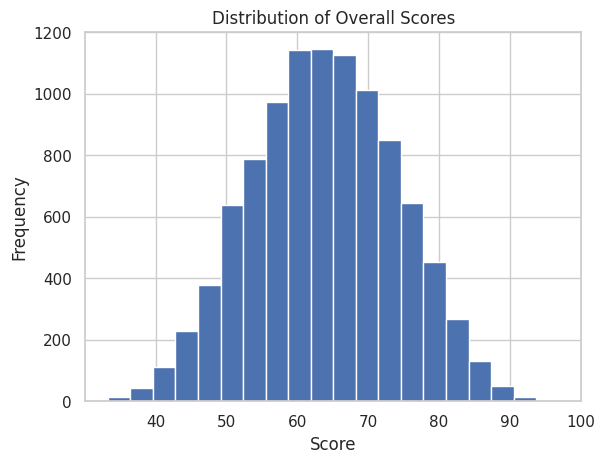

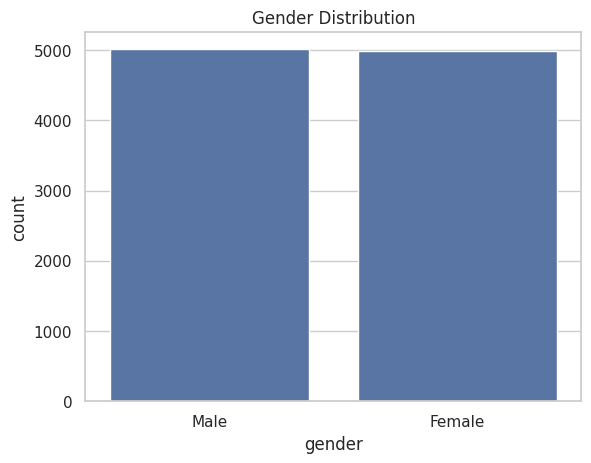

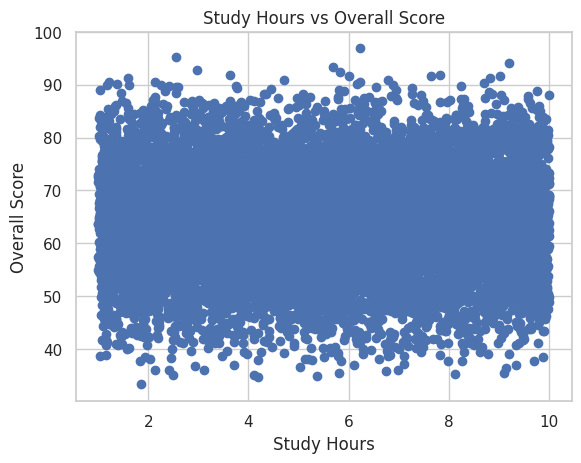

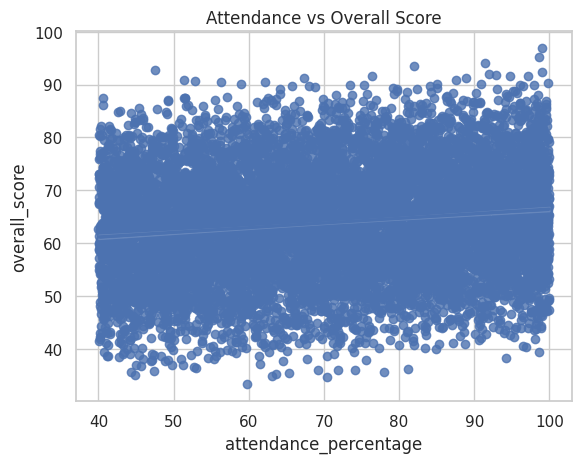

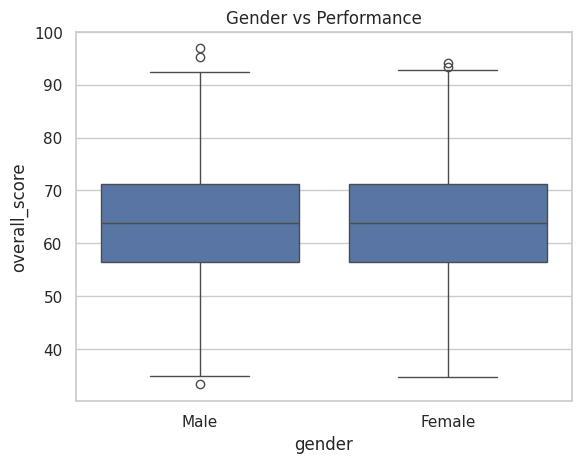

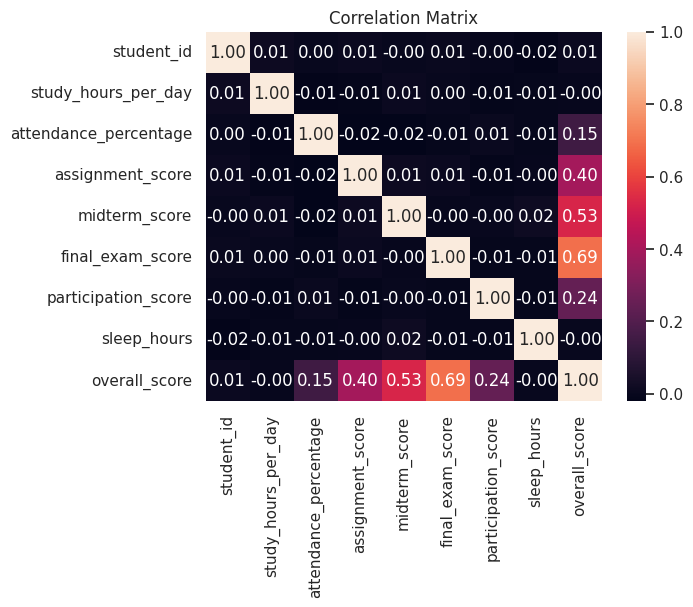

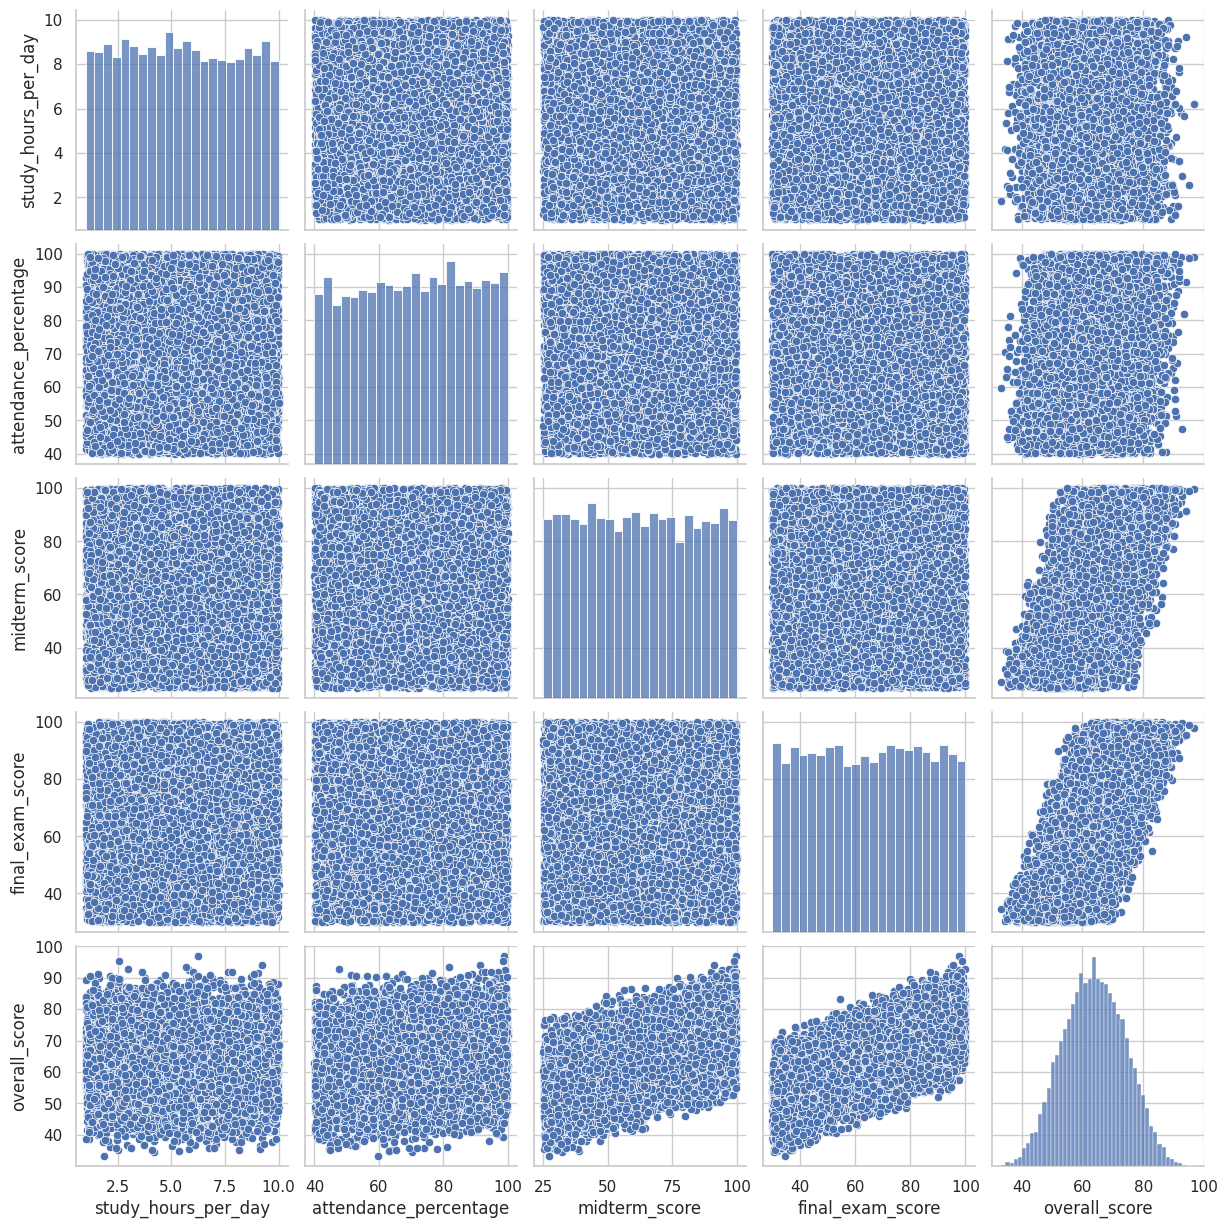

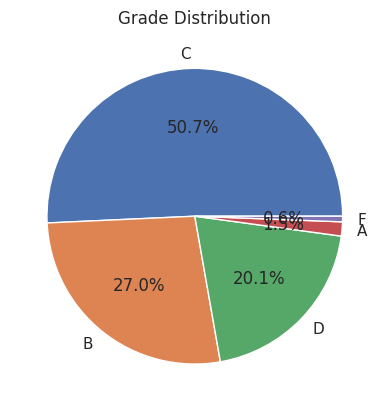

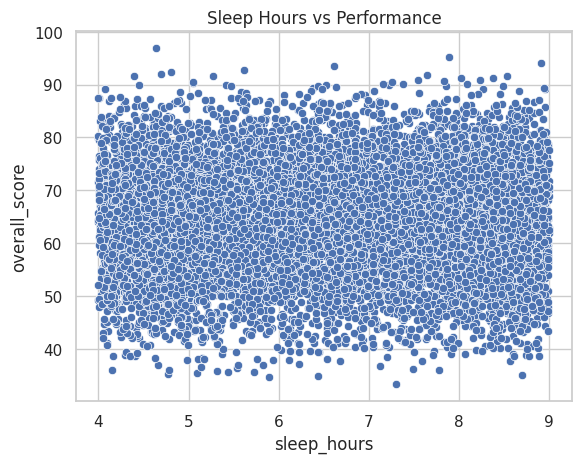

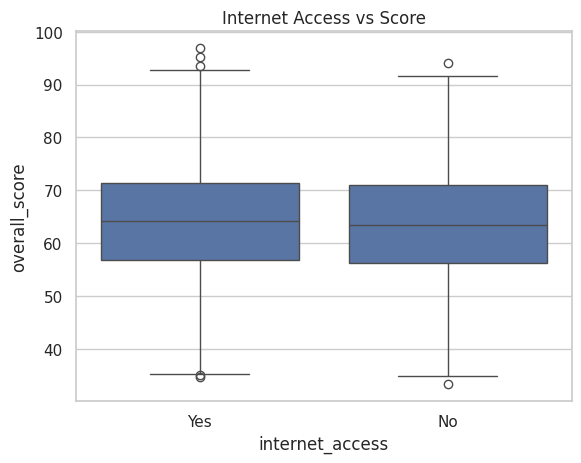

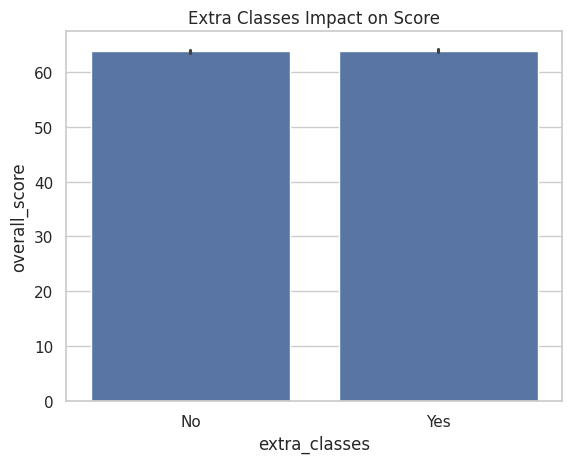

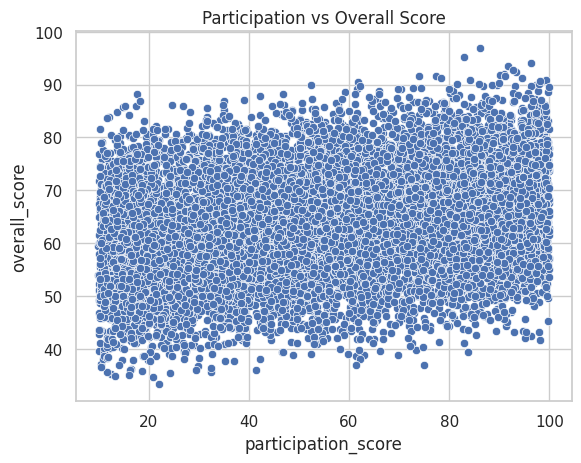

In [13]:

# Style
sns.set(style="whitegrid")

print(df.head())
print(df.info())

# ===============================
# 4. Histogram (Distribution)
# ===============================
plt.figure()
plt.hist(df['overall_score'], bins=20)
plt.title("Distribution of Overall Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# ===============================
# 5. Gender Count Plot
# ===============================
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

# ===============================
# 6. Study Hours vs Overall Score
# ===============================
plt.figure()
plt.scatter(df['study_hours_per_day'], df['overall_score'])
plt.title("Study Hours vs Overall Score")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.show()

# ===============================
# 7. Attendance vs Score (Regression)
# ===============================
plt.figure()
sns.regplot(x='attendance_percentage', y='overall_score', data=df)
plt.title("Attendance vs Overall Score")
plt.show()

# ===============================
# 8. Box Plot (Gender vs Score)
# ===============================
plt.figure()
sns.boxplot(x='gender', y='overall_score', data=df)
plt.title("Gender vs Performance")
plt.show()

# ===============================
# 9. Correlation Heatmap
# ===============================
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ===============================
# 10. Pairplot (Multiple Relations)
# ===============================
sns.pairplot(df[['study_hours_per_day', 'attendance_percentage',
                 'midterm_score', 'final_exam_score', 'overall_score']])
plt.show()

# ===============================
# 11. Grade Distribution (Pie Chart)
# ===============================
plt.figure()
grade_counts = df['grade'].value_counts()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.show()

# ===============================
# 12. Sleep vs Performance
# ===============================
plt.figure()
sns.scatterplot(x='sleep_hours', y='overall_score', data=df)
plt.title("Sleep Hours vs Performance")
plt.show()

# ===============================
# 13. Internet Access Impact
# ===============================
plt.figure()
sns.boxplot(x='internet_access', y='overall_score', data=df)
plt.title("Internet Access vs Score")
plt.show()

# ===============================
# 14. Extra Classes Impact
# ===============================
plt.figure()
sns.barplot(x='extra_classes', y='overall_score', data=df)
plt.title("Extra Classes Impact on Score")
plt.show()

# ===============================
# 15. Participation vs Score
# ===============================
plt.figure()
sns.scatterplot(x='participation_score', y='overall_score', data=df)
plt.title("Participation vs Overall Score")
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy: 0.9875
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.68      0.81        31
           1       0.97      1.00      0.99       541
           2       0.99      1.00      1.00      1015
           3       0.99      0.99      0.99       401
           4       1.00      0.58      0.74        12

    accuracy                           0.99      2000
   macro avg       0.99      0.85      0.90      2000
weighted avg       0.99      0.99      0.99      2000


===== Decision Tree =====
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00       541
           2       1.00      1.00      1.00      1015
           3       1.00      1.00      1.00       401
           4       1.00      1.00      1.00        12

    accuracy                           1.00   

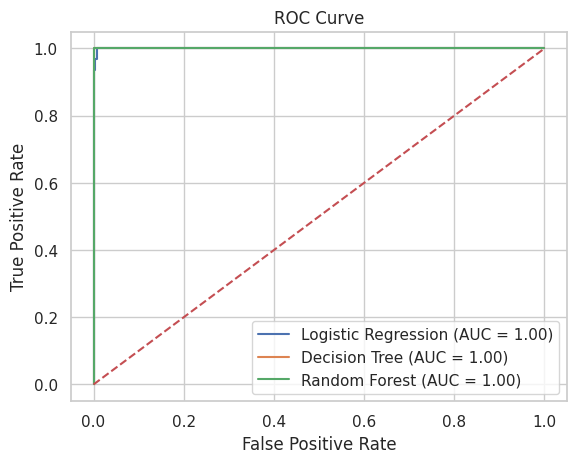

In [14]:
# ======================================
# 1. Import Libraries
# ======================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# ======================================
# 3. Define Target & Features
# ======================================
# Target = grade (classification problem)
target = 'grade'

X = df.drop(columns=[target, 'student_id'])  # remove ID (not useful)
y = df[target]

# ======================================
# 4. Train-Test Split (NO DATA LEAKAGE)
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# 5. Label Encoding (ONLY FIT ON TRAIN)
# ======================================
label_encoders = {}

for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # no fit here → no leakage
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

# ======================================
# 6. Feature Scaling
# ======================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================
# 7. Models
# ======================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# ======================================
# 8. Training + Evaluation
# ======================================
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    
    print("Classification Report:\n", classification_report(y_test, y_pred))

# ======================================
# 9. ROC Curve (One-vs-Rest for Multi-class)
# ======================================
from sklearn.preprocessing import label_binarize

# Convert target to binary format
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot only first class ROC (for simplicity)
        plt.plot(fpr[0], tpr[0], label=f"{name} (AUC = {roc_auc[0]:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!